In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

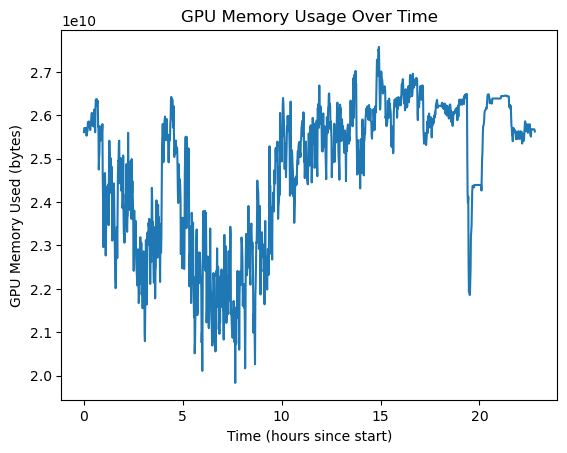

In [9]:
df = pd.read_csv("pod_gpu_memory_used_bytes_anon.csv")

df["timestamp_anon"] = pd.to_numeric(df["timestamp_anon"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

#remove rows where timestamp is missing or "value" is missing"
df = df.dropna(subset=["timestamp_anon", "value"])

# sort table by time
df = df.sort_values("timestamp_anon")

# find earliest timestamp
t_start = df["timestamp_anon"].min()

# the size of each time window to 1 minute
BIN_SIZE = 60

df["time_bin"] = (df["timestamp_anon"] // BIN_SIZE) * BIN_SIZE

#group data by each time_bin
mem_ts = df.groupby("time_bin")["value"].mean().reset_index()

#convert seconds to hours since start
mem_ts["time_hours"] = (mem_ts["time_bin"] - t_start) / 3600

plt.figure()
plt.plot(mem_ts["time_hours"], mem_ts["value"])

plt.xlabel("Time (hours since start)")
plt.ylabel("GPU Memory Used (bytes)")
plt.title("GPU Memory Usage Over Time")

plt.show()